<a href="https://colab.research.google.com/github/Raoina/Spectra-2-Image/blob/main/notebooks/Image_Transformation/%2002_GAF_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/LUCAS.SOIL_corr.csv'

In [3]:
import pandas as pd

df = pd.read_csv(file_path)

df.head()

/tmp/ipython-input-3672932280.py:3: DtypeWarning: Columns (1,2,4216,4231,4234,4237,4274) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Unnamed: 0,sample.ID,ID,date,spc.400,spc.400.5,spc.401,spc.401.5,spc.402,spc.402.5,...,WRBLV1,WRBADJ1,PARMADO1,PARMADO2,PARMADO3,PARMASE1,PARMASE2,PARMASE3,MIN_TOP,mineral
0,4,100,100,2011-01-24 16:02:25,0.831705,0.839111,0.846473,0.853773,0.860988,0.868098,...,CM,dy,3.0,31.0,310.0,5.0,56.0,561.0,KQ,mineral
1,5,1000,1000,2010-09-30 14:50:01,0.706027,0.714901,0.723727,0.732480,0.741142,0.749684,...,CM,dy,3.0,31.0,311.0,3.0,31.0,310.0,KQ,mineral
2,6,10000,10000,2010-10-19 12:06:16,0.666238,0.676472,0.686654,0.696757,0.706753,0.716615,...,CM,ca,2.0,21.0,214.0,0.0,0.0,0.0,MS,mineral
3,7,10001,10001,2010-10-19 15:00:01,0.698136,0.706548,0.714909,0.723197,0.731384,0.739448,...,CM,dy,3.0,31.0,310.0,4.0,42.0,420.0,KQ,mineral
4,8,10002,10002,2011-04-30 12:26:27,0.675433,0.684820,0.694163,0.703438,0.712620,0.721693,...,LV,ha,7.0,71.0,710.0,6.0,62.0,620.0,M,mineral


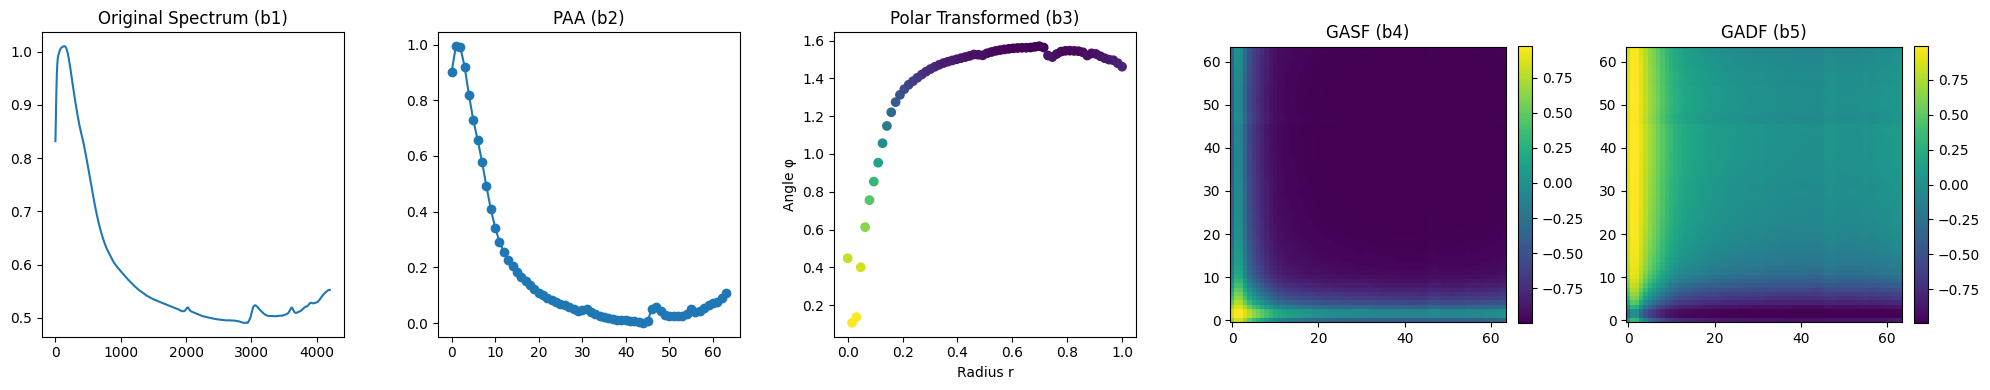

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. Select one sample ----------
row = df.iloc[0]
spectrum = row.filter(like="spc.")
intensity = spectrum.values.astype(float)

# ---------- 2. Normalization to [0,1] ----------
min_val, max_val = intensity.min(), intensity.max()
normalized = (intensity - min_val) / (max_val - min_val)

# ---------- 3. Piecewise Aggregate Approximation (PAA) ----------
def paa(series, segments):
    n = len(series)
    k = n // segments
    paa_result = []
    for i in range(segments):
        start = i * k
        end = start + k
        paa_result.append(series[start:end].mean())
    return np.array(paa_result)

segments = 65   # number of reduced points
paa_series = paa(normalized, segments)

# ---------- 4. Polar transformation ----------
phi = np.arccos(paa_series)         # angle
r = np.linspace(0, 1, len(paa_series))  # radius (normalized index)

# ---------- 5. Build GASF and GADF ----------
phi_matrix = np.outer(phi, np.ones_like(phi))
GASF = np.cos(phi_matrix + phi_matrix.T)
GADF = np.sin(phi_matrix - phi_matrix.T)

# ---------- 6. Visualization ----------
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

# (b1) Original spectrum
axs[0].plot(intensity)
axs[0].set_title("Original Spectrum (b1)")

# (b2) PAA
axs[1].plot(paa_series, marker="o")
axs[1].set_title("PAA (b2)")

# (b3) Polar transformed
axs[2].scatter(r, phi, c=paa_series, cmap="viridis")
axs[2].set_title("Polar Transformed (b3)")
axs[2].set_xlabel("Radius r")
axs[2].set_ylabel("Angle φ")

# (b4) GASF
im1 = axs[3].imshow(GASF, cmap="viridis", origin="lower")
axs[3].set_title("GASF (b4)")
plt.colorbar(im1, ax=axs[3], fraction=0.046, pad=0.04)

# (b5) GADF
im2 = axs[4].imshow(GADF, cmap="viridis", origin="lower")
axs[4].set_title("GADF (b5)")
plt.colorbar(im2, ax=axs[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

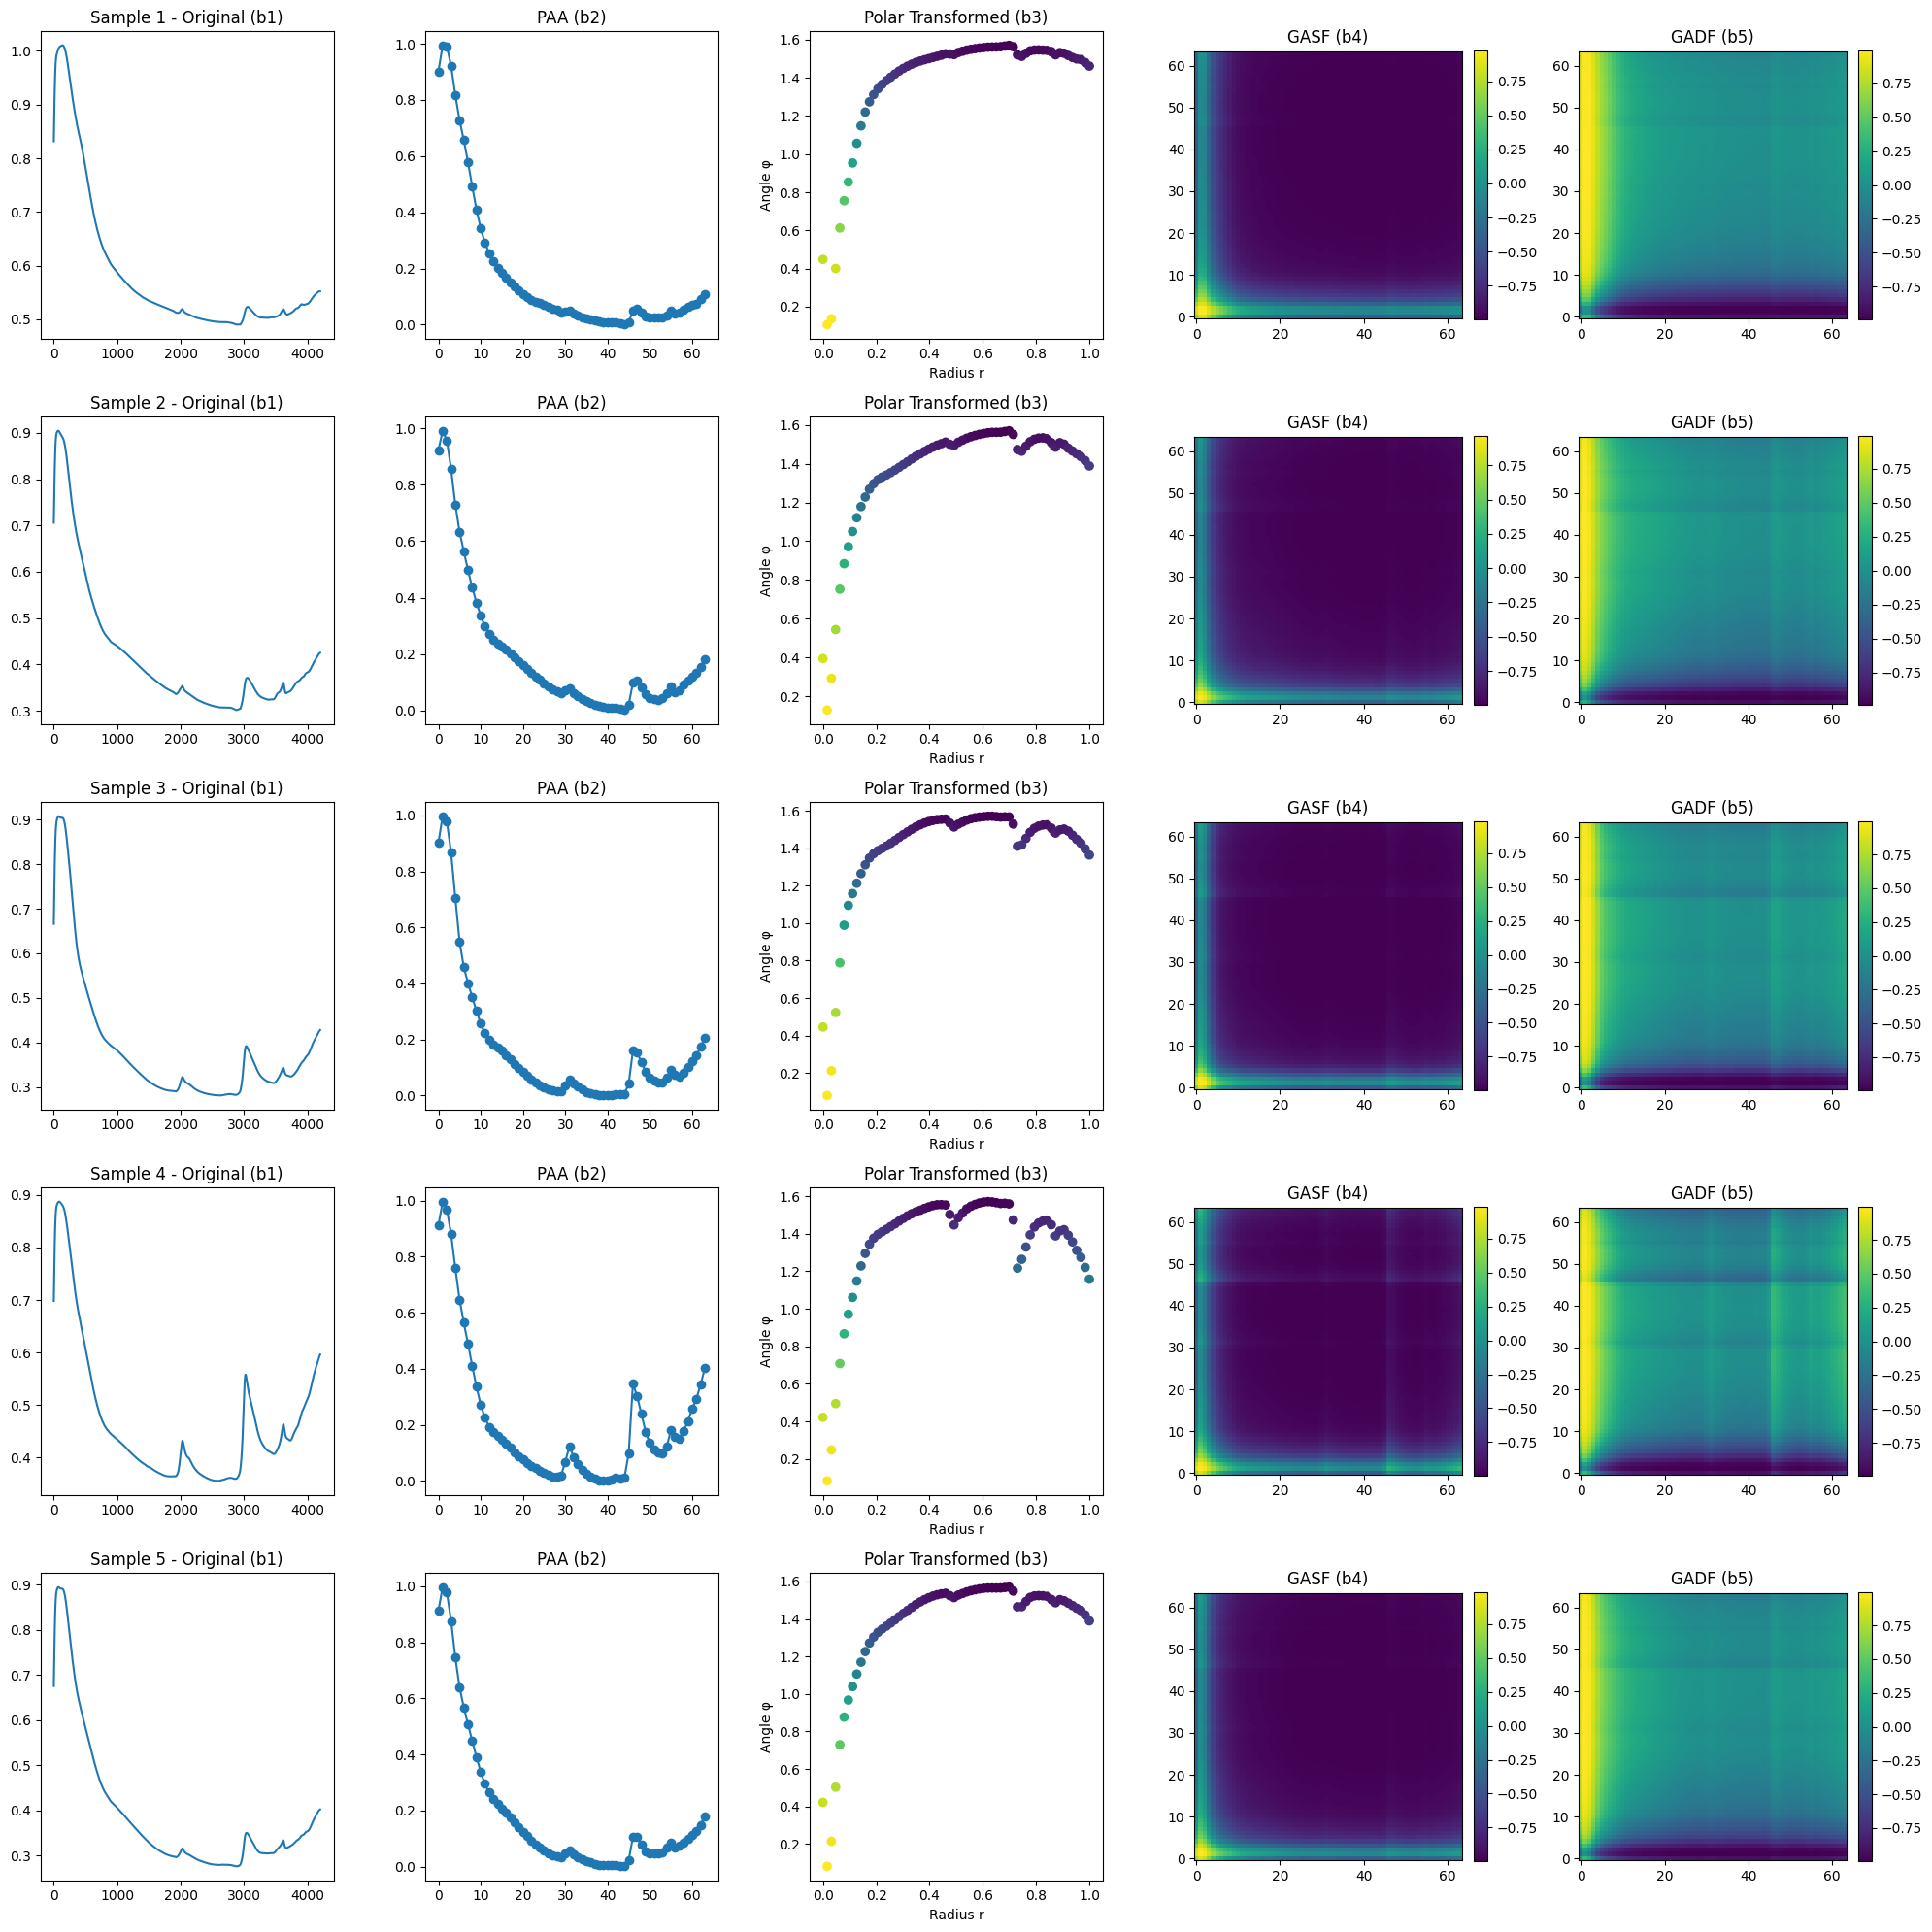

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helper function ----------
def paa(series, segments):
    n = len(series)
    k = n // segments
    return np.array([series[i*k:(i+1)*k].mean() for i in range(segments)])

def compute_gaf(intensity, segments=64):
    # Normalize [0,1]
    min_val, max_val = intensity.min(), intensity.max()
    normalized = (intensity - min_val) / (max_val - min_val)

    # PAA
    paa_series = paa(normalized, segments)

    # Polar transform
    phi = np.arccos(paa_series)  # angle
    r = np.linspace(0, 1, len(paa_series))

    # GASF & GADF
    phi_matrix = np.outer(phi, np.ones_like(phi))
    GASF = np.cos(phi_matrix + phi_matrix.T)
    GADF = np.sin(phi_matrix - phi_matrix.T)

    return normalized, paa_series, r, phi, GASF, GADF

# ---------- Apply to first N samples ----------
N = 5   # number of spectra
spectra = [df.iloc[i].filter(like="spc.").values.astype(float) for i in range(N)]

fig, axs = plt.subplots(N, 5, figsize=(20, 4*N))

for idx, spectrum in enumerate(spectra):
    norm, paa_series, r, phi, GASF, GADF = compute_gaf(spectrum, segments=64)

    # (b1) Original spectrum
    axs[idx, 0].plot(spectrum)
    axs[idx, 0].set_title(f"Sample {idx+1} - Original (b1)")

    # (b2) PAA
    axs[idx, 1].plot(paa_series, marker="o")
    axs[idx, 1].set_title("PAA (b2)")

    # (b3) Polar
    axs[idx, 2].scatter(r, phi, c=paa_series, cmap="viridis")
    axs[idx, 2].set_title("Polar Transformed (b3)")
    axs[idx, 2].set_xlabel("Radius r")
    axs[idx, 2].set_ylabel("Angle φ")

    # (b4) GASF
    im1 = axs[idx, 3].imshow(GASF, cmap="viridis", origin="lower")
    axs[idx, 3].set_title("GASF (b4)")
    plt.colorbar(im1, ax=axs[idx, 3], fraction=0.046, pad=0.04)

    # (b5) GADF
    im2 = axs[idx, 4].imshow(GADF, cmap="viridis", origin="lower")
    axs[idx, 4].set_title("GADF (b5)")
    plt.colorbar(im2, ax=axs[idx, 4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [5]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.6 MB/s eta 0:00:00


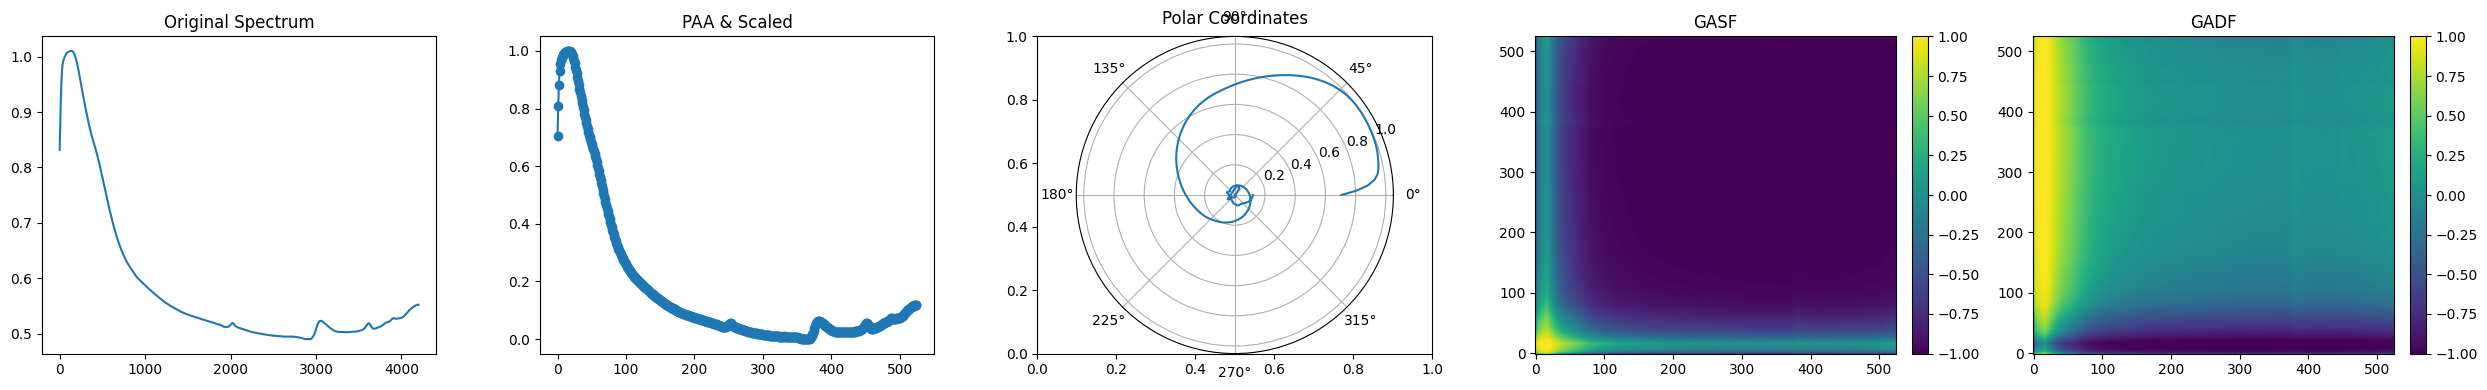

In [14]:
  import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyts.approximation import PiecewiseAggregateApproximation
from pyts.preprocessing import MinMaxScaler

# ---------------- 0. Load data ----------------
# Make sure your DataFrame `df` is loaded and contains columns starting with "spc."
# Example: df = pd.read_csv("your_spectrum.csv")

# ---------- 1. Select one sample ----------
row = df.iloc[0]  # Select the first sample (change index if needed)
spectrum = row.filter(like="spc.")  # Select only spectral columns
intensity = spectrum.values.astype(float)  # Convert to float array

# Adjust number of segments
segments = 512  # Or even len(intensity)

# Safe PAA window size
window_size = max(1, int(len(intensity) / segments))
paa = PiecewiseAggregateApproximation(window_size=window_size)
paa_series = paa.fit_transform(intensity.reshape(1, -1)).flatten()

# Scaling
scaler = MinMaxScaler()
scaled_paa = scaler.fit_transform(paa_series.reshape(1, -1)).flatten()

# Polar plot with more spiral loops
theta = np.linspace(0, 6 * np.pi, len(scaled_paa))  # You can increase this further
r = scaled_paa

# ---------- 5. Gramian Angular Fields ----------
phi = np.arccos(scaled_paa)
phi_matrix = np.outer(phi, np.ones_like(phi))
GASF = np.cos(phi_matrix + phi_matrix.T)
GADF = np.sin(phi_matrix - phi_matrix.T)

# ---------- 6. Visualization ----------
fig, axs = plt.subplots(1, 5, figsize=(25, 4))

# (a) Original Spectrum
axs[0].plot(intensity)
axs[0].set_title("Original Spectrum")

# (b) PAA & Scaled
axs[1].plot(scaled_paa, marker="o")
axs[1].set_title("PAA & Scaled")

# (c) Polar Coordinates (Spiral Style)
ax = fig.add_subplot(1, 5, 3, projection='polar')
ax.plot(theta, r)
ax.set_title("Polar Coordinates", va='bottom')
ax.grid(True)

# (d) GASF
im1 = axs[3].imshow(GASF, cmap="viridis", origin="lower", aspect='auto')
axs[3].set_title("GASF")
plt.colorbar(im1, ax=axs[3], fraction=0.046, pad=0.04)

# (e) GADF
im2 = axs[4].imshow(GADF, cmap="viridis", origin="lower", aspect='auto')
axs[4].set_title("GADF")
plt.colorbar(im2, ax=axs[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
